# Data Normalization Techniques

This notebook demonstrates the most common normalization methods used in data preprocessing and machine learning.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, Normalizer

# Reproducibility
np.random.seed(42)

## 1. Sample Dataset

We create a small dataset with features of very different scales — typical in real-world data.


In [2]:
data = {
    'Age':    [25, 32, 47, 51, 62, 21, 38, 44, 29, 55],
    'Income': [28000, 45000, 72000, 90000, 61000, 23000, 54000, 80000, 34000, 95000],
    'Score':  [3.2, 4.1, 2.8, 4.7, 3.9, 2.1, 4.5, 3.6, 2.9, 4.8]
}

df = pd.DataFrame(data)
print("Original Data:")
print(df)
print("\nStatistics:")
print(df.describe().round(2))

Original Data:
   Age  Income  Score
0   25   28000    3.2
1   32   45000    4.1
2   47   72000    2.8
3   51   90000    4.7
4   62   61000    3.9
5   21   23000    2.1
6   38   54000    4.5
7   44   80000    3.6
8   29   34000    2.9
9   55   95000    4.8

Statistics:
         Age    Income  Score
count  10.00     10.00  10.00
mean   40.40  58200.00   3.66
std    13.62  25750.08   0.90
min    21.00  23000.00   2.10
25%    29.75  36750.00   2.98
50%    41.00  57500.00   3.75
75%    50.00  78000.00   4.40
max    62.00  95000.00   4.80


## 2. Min-Max Normalization

Scales each feature to the range **[0, 1]**.

$$X_{norm} = \frac{X - X_{min}}{X_{max} - X_{min}}$$


In [3]:
min_max_scaler = MinMaxScaler()
df_minmax = pd.DataFrame(
    min_max_scaler.fit_transform(df),
    columns=df.columns
)

print("Min-Max Normalized Data:")
print(df_minmax.round(4))
print("\nRange after normalization:")
print(df_minmax.agg(['min', 'max']).round(4))

Min-Max Normalized Data:
      Age  Income   Score
0  0.0976  0.0694  0.4074
1  0.2683  0.3056  0.7407
2  0.6341  0.6806  0.2593
3  0.7317  0.9306  0.9630
4  1.0000  0.5278  0.6667
5  0.0000  0.0000  0.0000
6  0.4146  0.4306  0.8889
7  0.5610  0.7917  0.5556
8  0.1951  0.1528  0.2963
9  0.8293  1.0000  1.0000

Range after normalization:
     Age  Income  Score
min  0.0     0.0    0.0
max  1.0     1.0    1.0


## 3. Z-Score Standardization

Transforms features to have **mean = 0** and **std = 1**.

$$X_{std} = \frac{X - \mu}{\sigma}$$


In [4]:
standard_scaler = StandardScaler()
df_standard = pd.DataFrame(
    standard_scaler.fit_transform(df),
    columns=df.columns
)

print("Z-Score Standardized Data:")
print(df_standard.round(4))
print("\nMean and Std after standardization:")
print(df_standard.agg(['mean', 'std']).round(4))

Z-Score Standardized Data:
      Age  Income   Score
0 -1.1923 -1.2363 -0.5382
1 -0.6503 -0.5403  0.5148
2  0.5110  0.5649 -1.0063
3  0.8206  1.3017  1.2169
4  1.6723  0.1146  0.2808
5 -1.5019 -1.4409 -1.8253
6 -0.1858 -0.1719  0.9829
7  0.2787  0.8924 -0.0702
8 -0.8826 -0.9906 -0.8893
9  1.1303  1.5064  1.3339

Mean and Std after standardization:
         Age  Income   Score
mean  0.0000  0.0000  0.0000
std   1.0541  1.0541  1.0541


## 4. Robust Scaling

Uses the **median** and **IQR** — resistant to outliers.

$$X_{robust} = \frac{X - Q_2}{Q_3 - Q_1}$$


In [5]:
robust_scaler = RobustScaler()
df_robust = pd.DataFrame(
    robust_scaler.fit_transform(df),
    columns=df.columns
)

print("Robust Scaled Data:")
print(df_robust.round(4))

Robust Scaled Data:
      Age  Income   Score
0 -0.7901 -0.7152 -0.3860
1 -0.4444 -0.3030  0.2456
2  0.2963  0.3515 -0.6667
3  0.4938  0.7879  0.6667
4  1.0370  0.0848  0.1053
5 -0.9877 -0.8364 -1.1579
6 -0.1481 -0.0848  0.5263
7  0.1481  0.5455 -0.1053
8 -0.5926 -0.5697 -0.5965
9  0.6914  0.9091  0.7368


## 5. L2 (Unit Vector) Normalization

Scales each **row** (sample) to unit norm.

$$X_{l2} = \frac{X}{\|X\|_2}$$


In [6]:
l2_normalizer = Normalizer(norm='l2')
df_l2 = pd.DataFrame(
    l2_normalizer.fit_transform(df),
    columns=df.columns
)

print("L2 Normalized Data:")
print(df_l2.round(6))
print("\nRow norms (should all be ~1.0):")
print(np.linalg.norm(df_l2.values, axis=1).round(6))

L2 Normalized Data:
        Age    Income     Score
0  0.000893  1.000000  0.000114
1  0.000711  1.000000  0.000091
2  0.000653  1.000000  0.000039
3  0.000567  1.000000  0.000052
4  0.001016  0.999999  0.000064
5  0.000913  1.000000  0.000091
6  0.000704  1.000000  0.000083
7  0.000550  1.000000  0.000045
8  0.000853  1.000000  0.000085
9  0.000579  1.000000  0.000051

Row norms (should all be ~1.0):
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 6. Effect of Outliers

Comparing how Min-Max vs Robust scaling handle a dataset with outliers.


In [7]:
# Data with an outlier
income_with_outlier = np.array([28000, 45000, 72000, 90000, 61000,
                                 23000, 54000, 80000, 34000, 500000]).reshape(-1, 1)

minmax_out  = MinMaxScaler().fit_transform(income_with_outlier).flatten()
robust_out  = RobustScaler().fit_transform(income_with_outlier).flatten()

comparison = pd.DataFrame({
    'Original Income': income_with_outlier.flatten(),
    'Min-Max Scaled':  minmax_out.round(4),
    'Robust Scaled':   robust_out.round(4)
})
print(comparison.to_string(index=False))

 Original Income  Min-Max Scaled  Robust Scaled
           28000          0.0105        -0.7152
           45000          0.0461        -0.3030
           72000          0.1027         0.3515
           90000          0.1405         0.7879
           61000          0.0797         0.0848
           23000          0.0000        -0.8364
           54000          0.0650        -0.0848
           80000          0.1195         0.5455
           34000          0.0231        -0.5697
          500000          1.0000        10.7273


## 7. Visualization

Side-by-side comparison of all normalization techniques on the `Income` feature.


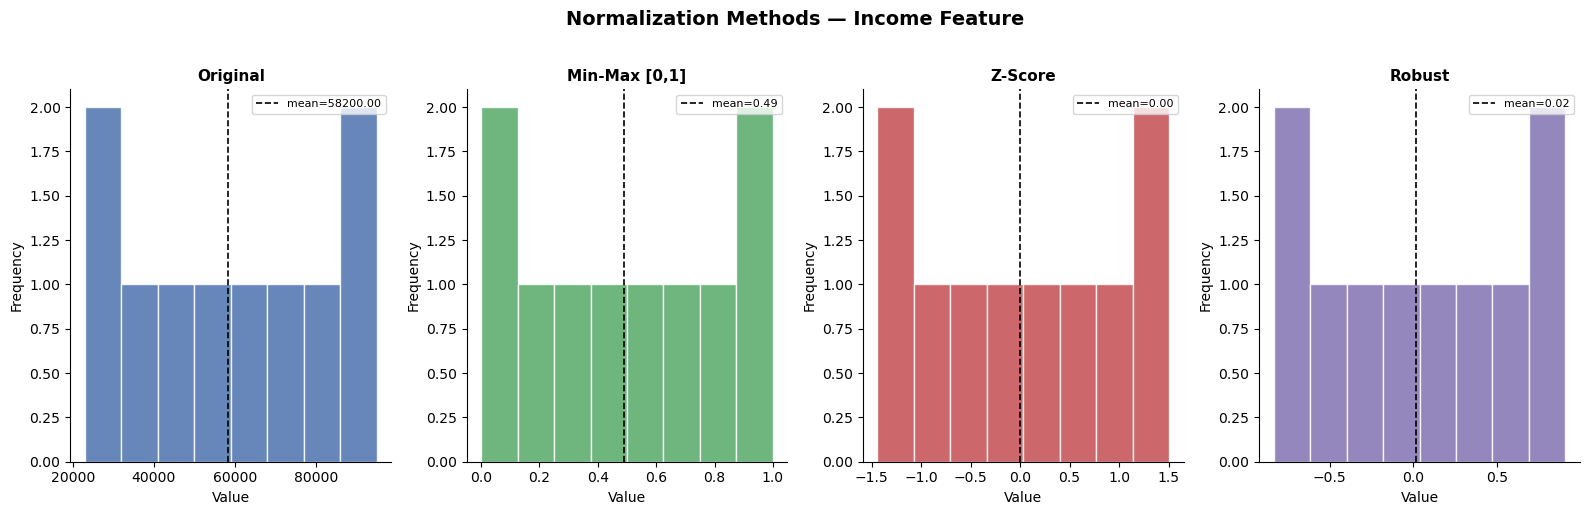

Plot saved as normalization_comparison.png


In [8]:
income = df[['Income']].values

methods = {
    'Original':      income.flatten(),
    'Min-Max [0,1]': MinMaxScaler().fit_transform(income).flatten(),
    'Z-Score':       StandardScaler().fit_transform(income).flatten(),
    'Robust':        RobustScaler().fit_transform(income).flatten(),
}

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle('Normalization Methods — Income Feature', fontsize=14, fontweight='bold', y=1.02)

colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

for ax, (title, values), color in zip(axes, methods.items(), colors):
    ax.hist(values, bins=8, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(title, fontsize=11, fontweight='semibold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.axvline(np.mean(values), color='black', linestyle='--', linewidth=1.2, label=f'mean={np.mean(values):.2f}')
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('normalization_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as normalization_comparison.png")

## 8. Summary Table

Quick reference for choosing the right normalization method.


In [9]:
summary = pd.DataFrame({
    'Method':        ['Min-Max', 'Z-Score', 'Robust', 'L2 Norm'],
    'Output Range':  ['[0, 1]', '~[-3, 3]', 'Centered', '[0, 1] per row'],
    'Outlier Safe':  ['No', 'No', 'Yes', 'Partial'],
    'Preserves':     ['Shape', 'Shape', 'Shape', 'Direction'],
    'Best For':      [
        'Neural nets, image pixels',
        'Linear models, PCA',
        'Data with outliers',
        'Text / cosine similarity'
    ]
})

print(summary.to_string(index=False))

 Method   Output Range Outlier Safe Preserves                  Best For
Min-Max         [0, 1]           No     Shape Neural nets, image pixels
Z-Score       ~[-3, 3]           No     Shape        Linear models, PCA
 Robust       Centered          Yes     Shape        Data with outliers
L2 Norm [0, 1] per row      Partial Direction  Text / cosine similarity
